<a href="https://colab.research.google.com/github/RonakkudalAI/Data-Analysis/blob/main/House_Rent_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
data_set = pd.read_csv("/content/House_Rent_Dataset.csv")
data_set

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [ ]:
data_set.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [ ]:
Category_Area_locality = data_set.groupby("Area Locality")["Rent"].sum()
Category_Area_locality

,Rent
Area Locality,
"Beeramguda, Ramachandra Puram, NH 9",200000
"in Boduppal, NH 2 2",4700
"in Erragadda, NH 9",12000
"in Miyapur, NH 9",15000
"117 Residency, Chembur East",47000
...,...
"vanamali chs ghatla, Ghatla",52000
venkatapuram,13500
venkatesa perumal nagar,9000


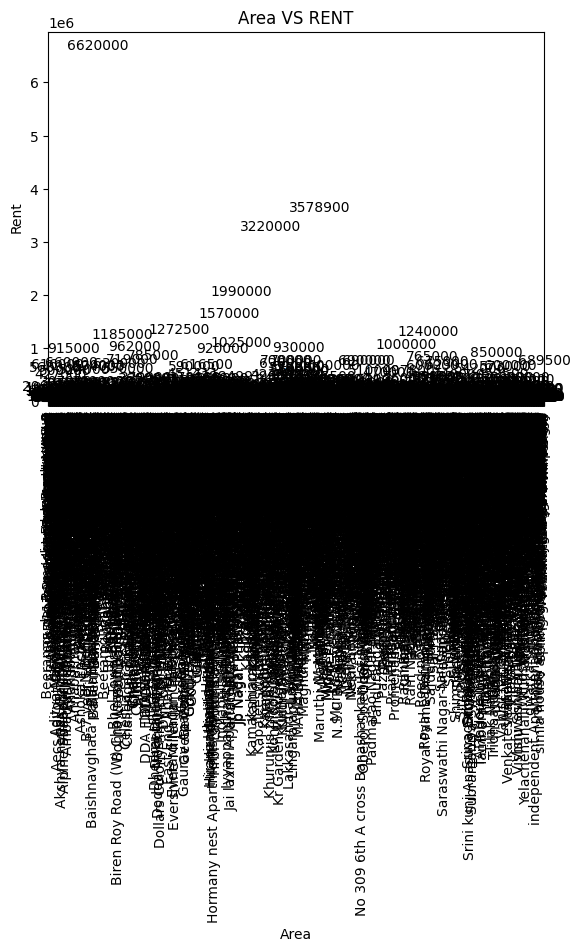

In [ ]:
import matplotlib.pyplot as plt
Category_Area_locality.plot(kind="bar")
plt.title("Area VS RENT")
plt.xlabel("Area")
plt.ylabel("Rent")
# plt.grid(axis ="y")
for i,values in enumerate(Category_Area_locality):
  plt.text(i,values,str(values),ha="center")
plt.show()

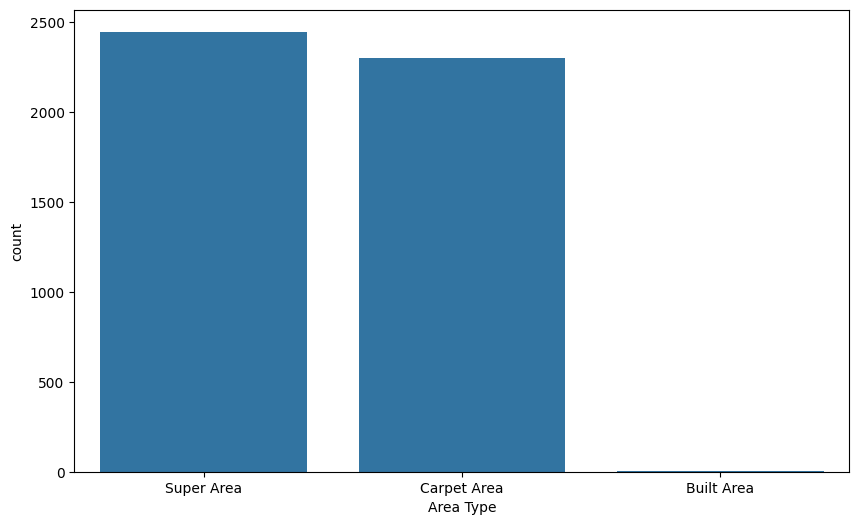

In [ ]:

plt.figure(figsize=(10,6))
sns.countplot(x="Area Type", data=data_set)
plt.xlabel("Area Type")
plt.show()

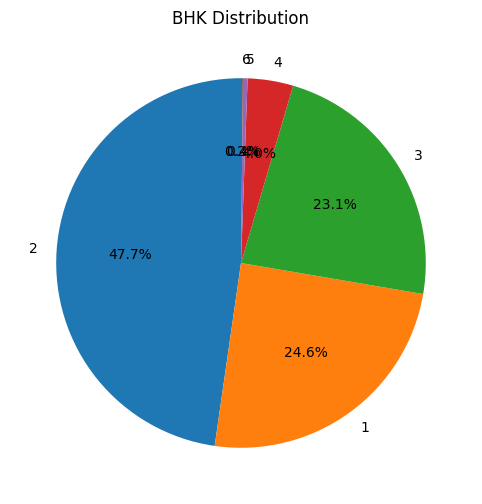

In [ ]:
BHK_count = data_set['BHK'].value_counts()
plt.figure(figsize=(10,6))
plt.pie(BHK_count,labels=BHK_count.index,autopct="%1.1f%%",startangle=90)
plt.title("BHK Distribution")
plt.show()

In [ ]:
#Box Plot
number_only = data_set.select_dtypes(include=["int64","float64"])


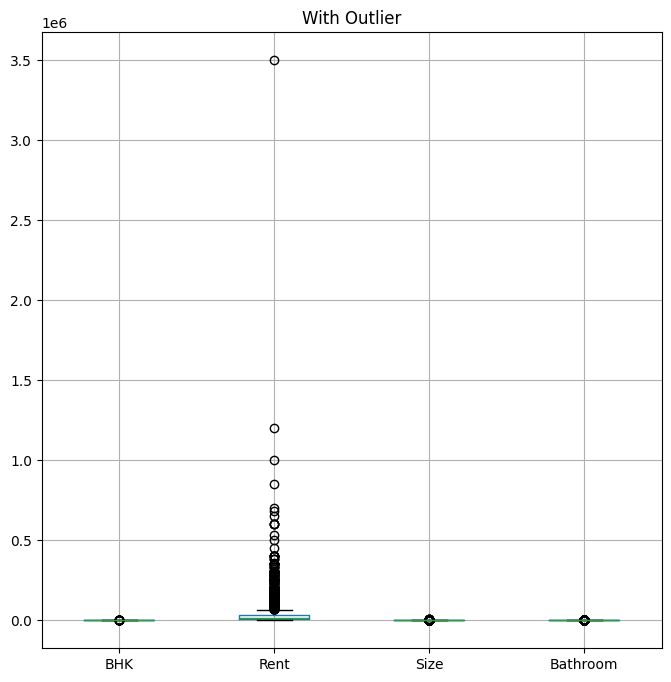

In [ ]:
plt.figure(figsize=(8,8))
number_only.boxplot()
plt.title("With Outlier")
plt.show()

In [ ]:
#Clean Outlier

Q1 = number_only.quantile(0.25)
Q3 = number_only.quantile(0.75)

IQR = Q3-Q1

lower_range = Q1-1.5*IQR
upper_range = Q3+1.5*IQR
df_clean = number_only[~((number_only<lower_range) | (number_only>upper_range)).any(axis=1)]
print(df_clean)

      BHK   Rent  Size  Bathroom
0       2  10000  1100         2
1       2  20000   800         1
2       2  17000  1000         1
3       2  10000   800         1
4       2   7500   850         1
...   ...    ...   ...       ...
4741    2  15000  1000         2
4742    3  29000  2000         3
4743    3  35000  1750         3
4744    3  45000  1500         2
4745    2  15000  1000         2

[4131 rows x 4 columns]


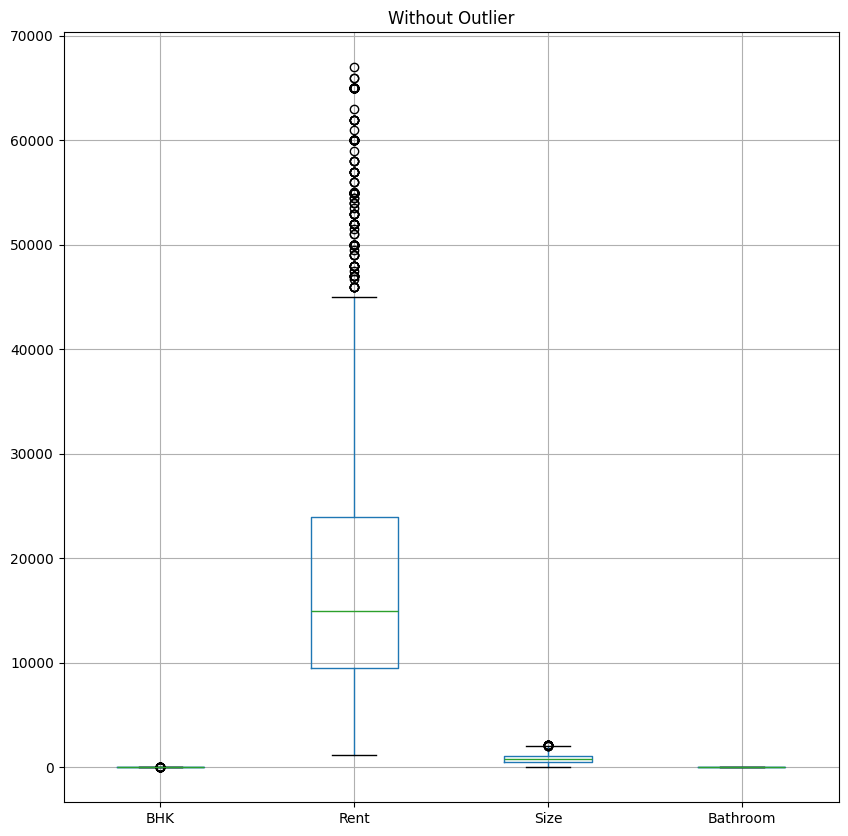

In [ ]:
plt.figure(figsize=(10,10))
df_clean.boxplot()
plt.title("Without Outlier")
plt.show()

In [ ]:
# Find Correlation

df_corr = df_clean.corr()
df_corr

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.369056,0.683202,0.729978
Rent,0.369056,1.000000,0.337017,0.481981
Size,0.683202,0.337017,1.000000,0.656973
Bathroom,0.729978,0.481981,0.656973,1.000000


<Axes: >

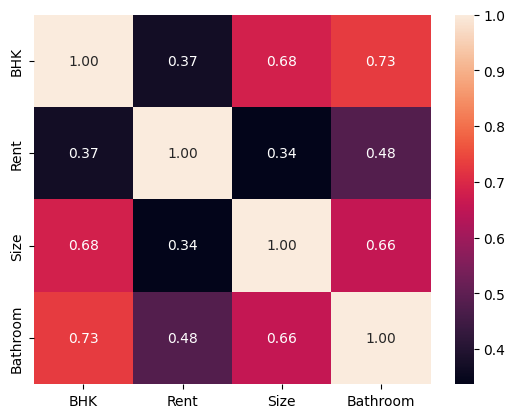

In [ ]:
sns.heatmap(df_corr,annot=True,fmt=".2f")

In [ ]:
# Find Corvariance

df_cov = df_clean.cov()
df_cov

,BHK,Rent,Size,Bathroom
BHK,0.491704,3.469615e+03,2.045176e+02,0.332308
Rent,3469.615191,1.797520e+08,1.928937e+06,4195.141748
Size,204.517596,1.928937e+06,1.822465e+05,182.077605
Bathroom,0.332308,4.195142e+03,1.820776e+02,0.421463


<Axes: >

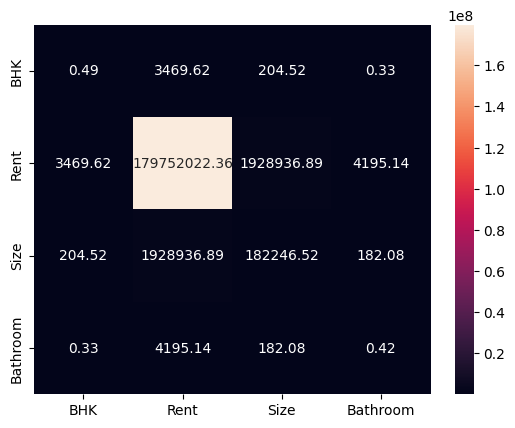

In [ ]:
sns.heatmap(df_cov,annot=True,fmt=".2f")

In [ ]:
Category_Area_locality = data_set.groupby("Area Locality")["Rent"].mean()
Category_Area_locality

,Rent
Area Locality,
"Beeramguda, Ramachandra Puram, NH 9",200000.000000
"in Boduppal, NH 2 2",4700.000000
"in Erragadda, NH 9",12000.000000
"in Miyapur, NH 9",15000.000000
"117 Residency, Chembur East",47000.000000
...,...
"vanamali chs ghatla, Ghatla",52000.000000
venkatapuram,13500.000000
venkatesa perumal nagar,9000.000000


(array([-500.,    0.,  500., 1000., 1500., 2000., 2500.]),
 [Text(-500.0, 0, 'Sahakara Nagar'),
  Text(0.0, 0, ' Beeramguda, Ramachandra Puram, NH 9'),
  Text(500.0, 0, 'Dodda Nekkundi Extension, Kartik Nagar, Outer Ring Road'),
  Text(1000.0, 0, 'Khar West'),
  Text(1500.0, 0, 'Paschim Apartments, Prabhadevi'),
  Text(2000.0, 0, 'Tilak Nagar, Jayanagar, bannerghatta main Road'),
  Text(2500.0, 0, '')])

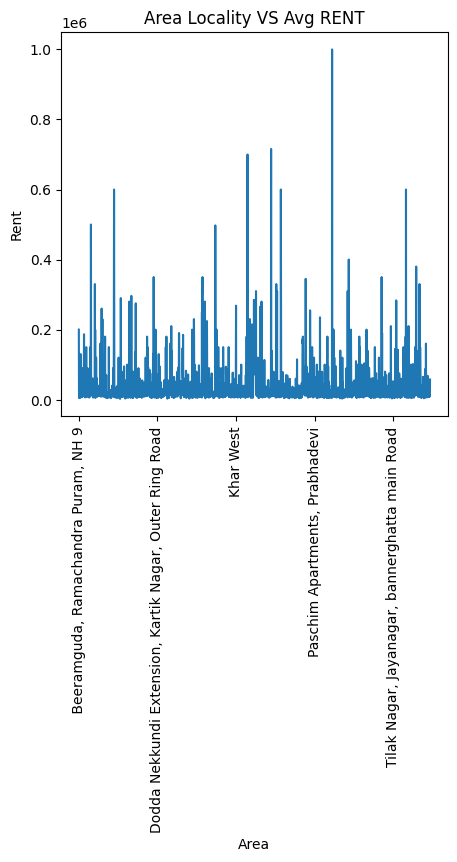

In [ ]:
Category_Area_locality.plot(kind="line")
plt.title("Area Locality VS Avg RENT")
plt.xlabel("Area")
plt.ylabel("Rent")
plt.tight_layout()
plt.xticks(rotation=90)

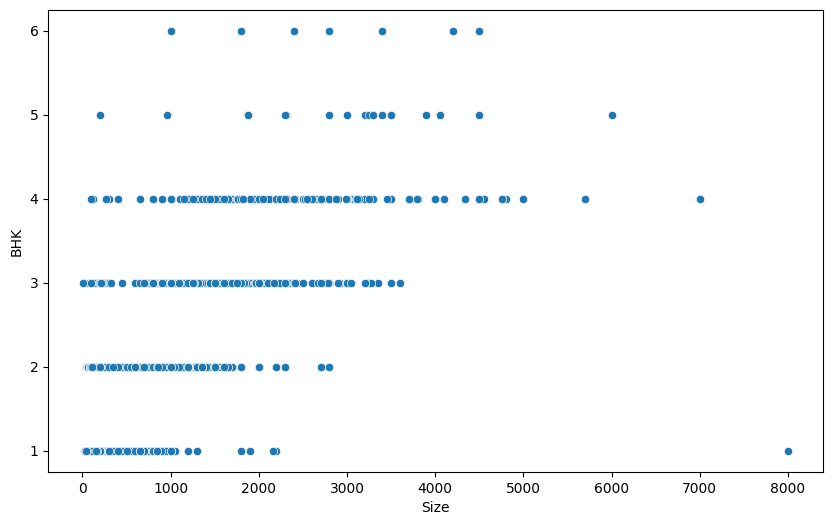

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Size",y="BHK" ,data=data_set)
plt.xlabel("Relation between Size and BHK")
plt.xlabel("Size")
plt.ylabel("BHK")
plt.show()

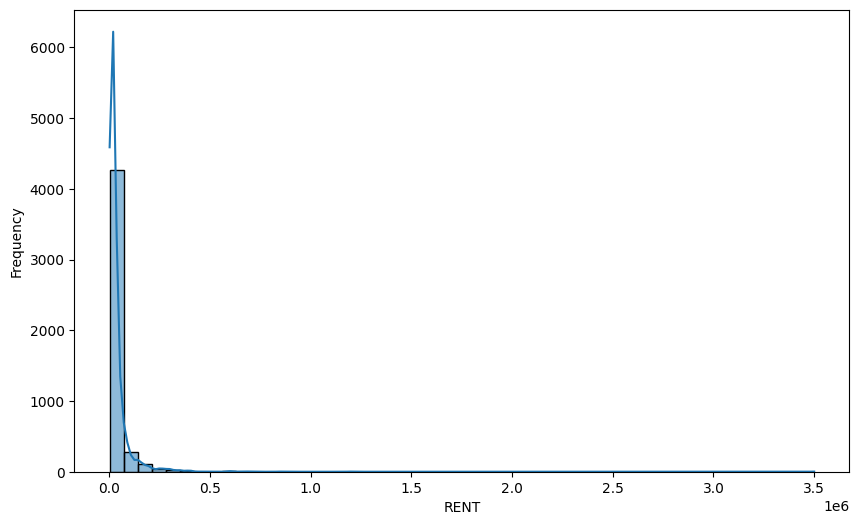

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data_set["Rent"],bins=50,kde=True)
plt.xlabel("Distribution of Rent")
plt.xlabel("RENT")
plt.ylabel("Frequency")
plt.show()

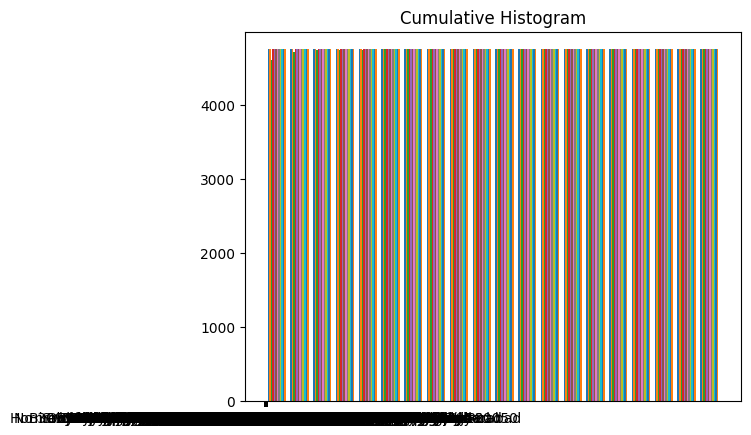

In [ ]:
plt.hist(data_set, cumulative=True, bins=20)
plt.title("Cumulative Histogram")
plt.show()

In [ ]:
avg_Rent = data_set.groupby("Floor")["Rent"].mean()
avg_Rent

,Rent
Floor,
1,15000.000000
1 out of 1,22667.522388
1 out of 10,30500.000000
1 out of 11,30000.000000
1 out of 12,33500.000000
...,...
Upper Basement out of 4,7500.000000
Upper Basement out of 40,150000.000000
Upper Basement out of 5,15500.000000


(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177

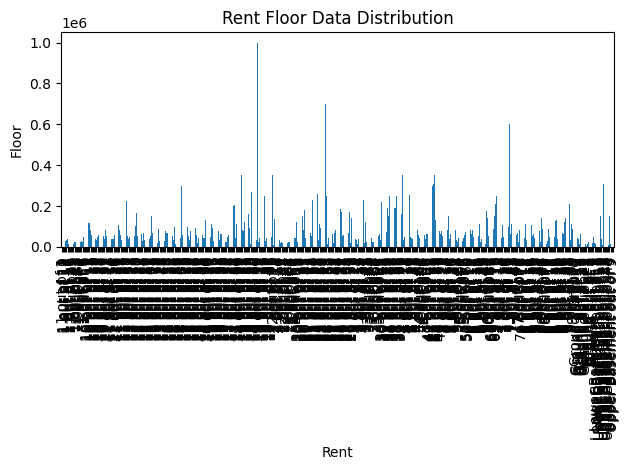

In [ ]:
avg_Rent.plot(kind="bar")
plt.title("Rent Floor Data Distribution")
plt.xlabel("Rent")
plt.ylabel("Floor")
plt.tight_layout()
plt.xticks(rotation=90)

In [ ]:
a = data_set['Floor'].unique()
print(len(a))

480


Label Encoder --categorical (text) data → numerical values
Constructor - LableEncoder()
Fit()-unique categories
Transform data--Converts data into numbers

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
b = encoder.fit_transform(a)

print1 = np.sort(b)

for i in print1:
    print(i,end = " ")

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 27

In [ ]:
df1 = data_set.select_dtypes(include=["object"]).columns
df1

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object')

In [ ]:
from sklearn .preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in df1:
  data_set[col]=encoder.fit_transform(data_set[col])
print(data_set)

      Posted On  BHK   Rent  Size  Floor  Area Type  Area Locality  City  \
0            26    2  10000  1100    455          2            221     4   
1            21    2  20000   800     14          2           1527     4   
2            24    2  17000  1000     14          2           1760     4   
3            73    2  10000   800     10          2            526     4   
4            17    2   7500   850     10          1           1890     4   
...         ...  ...    ...   ...    ...        ...            ...   ...   
4741         26    2  15000  1000    271          1            219     3   
4742         23    3  29000  2000     16          2           1214     3   
4743         79    3  35000  1750    271          1            724     3   
4744         75    3  45000  1500    226          1            590     3   
4745         12    2  15000  1000    313          1           1915     3   

      Furnishing Status  Tenant Preferred  Bathroom  Point of Contact  
0              

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}   # ✅ create dictionary

for col in data_set.columns:
    encoder = LabelEncoder()
    data_set[col] = encoder.fit_transform(data_set[col])
    encoders[col] = encoder   # ✅ store encoder

print(data_set)

      Posted On  BHK  Rent  Size  Floor  Area Type  Area Locality  City  \
0            26    1    56   334    455          2            221     4   
1            21    1    91   223     14          2           1527     4   
2            24    1    78   302     14          2           1760     4   
3            73    1    56   223     10          2            526     4   
4            17    1    40   243     10          1           1890     4   
...         ...  ...   ...   ...    ...        ...            ...   ...   
4741         26    1    73   302    271          1            219     3   
4742         23    2   116   529     16          2           1214     3   
4743         79    2   131   491    271          1            724     3   
4744         75    2   147   446    226          1            590     3   
4745         12    1    73   302    313          1           1915     3   

      Furnishing Status  Tenant Preferred  Bathroom  Point of Contact  
0                     2    

In [ ]:
for col in data_set.columns:
    data_set[col] = encoders[col].inverse_transform(data_set[col])

print(data_set)

      Posted On  BHK   Rent  Size  Floor  Area Type  Area Locality  City  \
0            26    2  10000  1100    455          2            221     4   
1            21    2  20000   800     14          2           1527     4   
2            24    2  17000  1000     14          2           1760     4   
3            73    2  10000   800     10          2            526     4   
4            17    2   7500   850     10          1           1890     4   
...         ...  ...    ...   ...    ...        ...            ...   ...   
4741         26    2  15000  1000    271          1            219     3   
4742         23    3  29000  2000     16          2           1214     3   
4743         79    3  35000  1750    271          1            724     3   
4744         75    3  45000  1500    226          1            590     3   
4745         12    2  15000  1000    313          1           1915     3   

      Furnishing Status  Tenant Preferred  Bathroom  Point of Contact  
0              

In [ ]:
data_set.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [ ]:
# Feature Selection----
# Input Feature - Idependent Column
# Output Feature - Dependent Column -Target Column

x = data_set[['Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status']]

y= data_set["Rent"]


In [ ]:
number_only = data_set.select_dtypes(include=["int64","float64"])



In [ ]:
# Remove Outlier
#Clean Outlier

Q1 = number_only.quantile(0.25)
Q3 = number_only.quantile(0.75)

IQR = Q3-Q1

lower_range = Q1-1.5*IQR
upper_range = Q3+1.5*IQR
df_clean = number_only[~((number_only<lower_range) | (number_only>upper_range)).any(axis=1)]
print(df_clean)

      Posted On  BHK   Rent  Size  Floor  Area Type  Area Locality  City  \
0            26    2  10000  1100    455          2            221     4   
1            21    2  20000   800     14          2           1527     4   
2            24    2  17000  1000     14          2           1760     4   
3            73    2  10000   800     10          2            526     4   
5             7    2   7000   600    447          2           1975     4   
...         ...  ...    ...   ...    ...        ...            ...   ...   
4737         76    3  15000  1500    466          2             71     3   
4740         41    2  12000  1350    192          2           1434     3   
4741         26    2  15000  1000    271          1            219     3   
4742         23    3  29000  2000     16          2           1214     3   
4743         79    3  35000  1750    271          1            724     3   

      Furnishing Status  Tenant Preferred  Bathroom  Point of Contact  
0              

In [ ]:
# Find Correlation

df_corr = df_clean.corr()
df_corr

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
Posted On,1.000000,0.051540,0.146901,0.093923,-0.002897,-0.187886,0.028866,0.029697,-0.036886,NaN,0.099132,-0.241081
BHK,0.051540,1.000000,0.355964,0.677579,-0.042162,-0.044169,0.024038,-0.052735,-0.106994,NaN,0.727587,-0.021230
Rent,0.146901,0.355964,1.000000,0.343227,-0.001728,-0.329846,-0.020462,0.296452,-0.223184,NaN,0.463055,-0.526548
Size,0.093923,0.677579,0.343227,1.000000,-0.025497,0.024390,0.005313,-0.113413,-0.169992,NaN,0.664980,-0.008608
Floor,-0.002897,-0.042162,-0.001728,-0.025497,1.000000,-0.021847,-0.005993,0.083970,0.004754,NaN,-0.037697,-0.003508
Area Type,-0.187886,-0.044169,-0.329846,0.024390,-0.021847,1.000000,0.015947,-0.201762,0.043227,NaN,-0.052563,0.553233
Area Locality,0.028866,0.024038,-0.020462,0.005313,-0.005993,0.015947,1.000000,-0.036026,0.015985,NaN,0.032376,0.011555
City,0.029697,-0.052735,0.296452,-0.113413,0.083970,-0.201762,-0.036026,1.000000,0.079732,NaN,-0.020391,-0.261800
Furnishing Status,-0.036886,-0.106994,-0.223184,-0.169992,0.004754,0.043227,0.015985,0.079732,1.000000,NaN,-0.143220,0.061148
Tenant Preferred,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

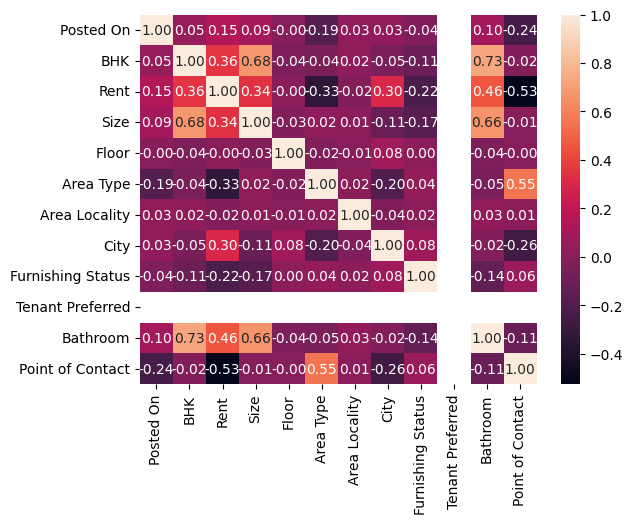

In [ ]:
sns.heatmap(df_corr,annot=True,fmt=".2f")

In [ ]:
# Feature Selection
x = df_clean[["Size","Bathroom"]]
y = df_clean["Rent"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#Data Split (Holdout method)-->>
from sklearn.model_selection import train_test_split



In [ ]:
# Feature Scaling--->
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [ ]:
# Fit only on training data
x_train_scale = scaler.fit_transform(x_train)

# ONLY transform test data (no fit)
x_test_scale = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()
LR_model.fit(x_train_scale, y_train)

LinearRegression()

In [ ]:
# Model Testion --->

y_pred = LR_model.predict(x_test_scale)
print(y_pred)

[19870.25015495 10848.558443   10942.46194647 19510.28672501
 10926.81136256 19275.52796635 10926.81136256 20214.56300099
 19901.55132277 10613.79968434 20058.05716188 19901.55132277
 20684.08051831 20997.09219652 10222.53508658 10926.81136256
 10692.0526039  19838.94898713 10770.30552345 20058.05716188
 10457.29384524 20058.05716188 19588.53964456 19934.41754899
 20684.08051831 19353.7808859  10613.79968434 28250.26792657
 19588.53964456 19635.49139629 10926.81136256 20918.83927697
 19823.29840322 18884.26336858 19557.23847674 10491.72512984
 10699.87789585 19901.55132277 29502.31463942 20605.82759875
 19275.52796635 20527.5746792  11083.31720166 19131.54259437
 20245.86416881 11005.06428211 20097.18362166 19588.53964456
 21231.85095518 10105.15570725 19510.28672501 10770.30552345
 10926.81136256 20058.05716188 19823.29840322 29032.7971221
 11161.57012122 20214.56300099 10848.558443   19463.33497328
 18649.50460992 19510.28672501 19400.73263763 20214.56300099
 10379.04092568 19119.022

In [ ]:
#Check model OverFitting

train_score = LR_model.score(x_train_scale,y_train)
test_score = LR_model.score(x_test_scale, y_test)

print("Train Score :",train_score*100)
print("Test Score :",test_score*100)

Train Score : 21.9658971005502
Test Score : 20.492379885059787


In [ ]:
from sklearn.linear_model import Ridge,Lasso

In [ ]:
Ridge = Ridge(alpha = 0.01)
Ridge.fit(x_train_scale, y_train)

train_score1 = Ridge.score(x_train_scale,y_train)
test_score1 = Ridge.score(x_test_scale,y_test)
print("Train Score:",train_score1*100)
print("Test Score:", test_score1*100)

Train Score: 21.965897100068876
Test Score: 20.492392672917802


In [ ]:
#Find alpha Values----->

from sklearn.model_selection import GridSearchCV

a = {"alpha":[0.01,0.1,1,10,100]}
b = GridSearchCV(Ridge,a,cv=5)
b.fit(x_train_scale,y_train)

print(b.best_params_)

{'alpha': 10}


In [ ]:
# Lasso
Lasso = Lasso(alpha = 0.1)
Lasso.fit(x_train_scale, y_train)

train_score1 = Lasso.score(x_train_scale,y_train)
test_score1 = Lasso.score(x_test_scale,y_test)
print("Train Score:",train_score1*100)
print("Test Score:", test_score1*100)

Train Score: 21.965897081282403
Test Score: 20.492476868029918


In [ ]:
#Find alpha Values----->

from sklearn.model_selection import GridSearchCV

a = {"alpha":[0.01,0.1,1,10,100]}
b = GridSearchCV(Lasso,a,cv=5)
b.fit(x_train_scale,y_train)

print(b.best_params_)

{'alpha': 10}


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score


In [ ]:
MAE = mean_absolute_error(y_test,y_pred)
print(MAE)

8331.155830776413


In [ ]:
print(df_clean["Rent"].min())

1200


In [ ]:
r2_score(y_test,y_pred)


0.20492379885059786